# 🚗 Electric Vehicle Sales Analysis & Forecasting in India
# 📌 Problem Statement

With the rapid adoption of Electric Vehicles (EVs) in India, businesses and policymakers need data-driven insights to understand sales patterns, regional demand, and future growth trends.

This project aims to analyze historical EV sales data across different regions, product categories, and customer segments to:

- Identify key drivers of EV adoption

- Analyze sales performance across time and geography

- Understand customer purchasing behavior

- Forecast future EV sales trends

The insights generated will help:

- Businesses optimize inventory and pricing strategies

- Companies identify high-growth regions and segments

- Policymakers evaluate the impact of EV adoption initiatives

# 🎯 Objectives

1. Perform exploratory data analysis (EDA) to uncover trends and patterns

2. Build an interactive dashboard for business stakeholders

3. Analyze time-based trends in EV sales

4. Develop a time series forecasting model to predict future sales

5. Generate actionable insights for decision-making

In [1]:
# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

# 📊 Dataset Column Description – EV Sales Data

## 🧾 Overview

This dataset represents electric vehicle (EV) sales transactions across various regions in India. Each row corresponds to a single sales transaction.

---

## 📌 Column Details

### 1. **Order_ID**

* Unique identifier for each sales transaction
* Format: `EV00001`, `EV00002`, etc.
* Used for tracking and referencing individual orders

---

### 2. **Order_Date**

* Date on which the vehicle purchase was made
* Format: `YYYY-MM-DD`
* Used for time series analysis, trend analysis, and forecasting

---

### 3. **Region**

* Broad geographical classification of the sale
* Values: North, South, East, West
* Helps analyze regional adoption patterns of EVs

---

### 4. **City**

* City where the transaction took place
* Represents urban demand centers
* Useful for identifying top-performing cities

---

### 5. **Product_Category**

* Type of electric vehicle sold
* Categories include:

  * 2-Wheeler EV
  * 4-Wheeler EV
  * Commercial EV
* Helps segment analysis by vehicle type

---

### 6. **Product_Name**

* Specific EV model sold
* Examples:

  * Ola S1
  * Ather 450X
  * Tata Nexon EV
* Enables product-level performance analysis

---

### 7. **Sales**

* Total transaction value (in INR ₹)
* Calculated as:
  **Sales = Price × Quantity**
* Key metric for revenue analysis

---

### 8. **Quantity**

* Number of units sold in a single transaction
* Helps in volume analysis and demand estimation

---

### 9. **Profit**

* Profit earned from the transaction (in INR ₹)
* Used to evaluate business performance

---

### 10. **Customer_Segment**

* Type of customer making the purchase
* Categories:

  * Individual
  * Corporate
  * Fleet
* Helps understand buying behavior

---

### 11. **Payment_Mode**

* Method used to complete the transaction
* Options include:

  * UPI
  * Loan
  * Lease
  * Cash
* Useful for financial and behavioral insights

---

## 🎯 Key Notes

* The dataset is structured for both **dashboarding** and **time series forecasting**
* Suitable for analyzing **growth trends, customer behavior, and regional adoption patterns**

---


In [3]:
# load the dataset
ev_df = pd.read_excel(r'dataset\ev_sales.xlsx')
ev_df.head(5)

FileNotFoundError: [Errno 2] No such file or directory: 'dataset\\ev_sales.xlsx'

In [ ]:
print(f"Shape of the data : {ev_df.shape}", end="\n\n")
print(f"No. of missing values in the data : \n{ev_df.isnull().sum()}", end="\n\n")
print(f"No. of duplicates values in the data : {ev_df.duplicated().sum()}")

In [ ]:
ev_df.info()

In [ ]:
# the Order_Date is of object datatype and is not in sequential order, so first convert into datetime then sort it
ev_df['Order_Date'] = pd.to_datetime(ev_df['Order_Date'])
ev_df = ev_df.sort_values(by='Order_Date')

# remove the Order_ID column
ev_df.drop(columns=['Order_ID'], inplace=True)
ev_df.head(5)

In [ ]:
# extract important time features
ev_df['Year'] = ev_df["Order_Date"].dt.year
ev_df['Month'] = ev_df["Order_Date"].dt.month
ev_df['Quarter'] = ev_df["Order_Date"].dt.quarter

ev_df.head(5)

For creating dashboard we will use Power BI, so export the data

In [ ]:
# export ev_df for creating dashboard and create a dataset for doing time series analysis and forecasting future sales
ev_sales = ev_df[['Order_Date', 'Sales', 'Quantity', 'Year', 'Month', 'Quarter']].copy()
ev_df.to_csv('ev_sales', index=False)

## **Univariate Analysis**

In [ ]:
def univariate_num(col):
    print(f"Summary Statistic: \n{ev_df[col].describe()}")
    print(f"Skewness: {ev_df[col].skew()}")

    # create 2 subplots
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))

    # plot the histogram
    sns.histplot(ev_df, x=col, kde=True, ax=ax[0])

    # plot the box plot
    sns.boxplot(ev_df, y=col, ax=ax[1])

    # set the title of the figure
    fig.suptitle(f"Distribution of {col}")

    plt.tight_layout()
    plt.show()

    print("="*100)
    print("="*100)

In [ ]:
num_cols = ['Sales', 'Quantity']
print(num_cols)

In [ ]:
for col in num_cols:
    univariate_num(col)

### **Insights**
1. The distribution of **Sales** and **Profit** column is right skewed with lots of outliers.
2. The **Quantity** distribution is fairly balanced, with a mode around 3 units, indicating that customers typically purchase around three vehicles per transaction.

## **Time Series Analysis**

In [ ]:
ev_sales1 = ev_sales.set_index('Order_Date').resample('D')[['Sales', 'Quantity']].sum()
ev_sales1.head(5)

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# plot the daily sales over time
fig1 = px.line(
    ev_sales1,
    y='Sales',
    markers='o',
    title='Sales Trend over time'
)

fig2 = px.line(
    ev_sales1,
    y='Quantity',
    markers='o',
    title='Demands Trend over time'
)

fig1.show()
fig2.show()

In [ ]:
# plot the monthly sales data over time
monthly_data = ev_sales1.resample('M')[['Sales', 'Quantity']].sum()

fig1 = px.line(
    monthly_data,
    y='Sales',
    markers='o',
    title='Monthly Sales Trend'
)

fig2 = px.line(
    monthly_data,
    y='Quantity',
    markers='o',
    title='Monthly Demands Trend'
)

fig1.show()
fig2.show()

## **Time Series Decomposition**

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

sales_decompose = seasonal_decompose(
    x=monthly_data['Sales'],
    model='multiplicative',
    period=12
)

sales_decompose.plot()
plt.show()

In [ ]:
quantity_decompose = seasonal_decompose(
    x=monthly_data['Quantity'],
    model='additive',
    period=12
)

quantity_decompose.plot()
plt.show()

In [ ]:
# extract important time features like month, year
monthly_data['Year'] = monthly_data.index.year
monthly_data['Month'] = monthly_data.index.month
monthly_data['Quarter'] = monthly_data.index.quarter
monthly_data['Day of Week'] = monthly_data.index.dayofweek
monthly_data.head(5)

## **Plotting Features over Time (Month)**

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(monthly_data, x='Month', y='Sales', ax=ax[0])
ax[0].set_title('Monthly Sales over Month')

sns.lineplot(monthly_data, x='Month', y='Quantity', ax=ax[1])
ax[1].set_title('Monthly Demands over Month')

plt.tight_layout()
plt.show()

## **Plotting Sales over Year by Month**

In [ ]:
plt.figure(figsize=(16, 4))

sns.set_style('darkgrid')

plt.title('Monthly Sales over Year')
sns.lineplot(monthly_data, x='Month', y='Sales', hue='Year', palette='cool', ci=None)

plt.show()

## **Correlation Plot**

In [ ]:
sns.heatmap(monthly_data.corr(), annot=True)

## **Box Plots**

### Yearly Distribution of Sales

In [ ]:
plt.title('Yearly Distribution of Sales')
sns.boxplot(monthly_data, x='Year', y='Sales')
plt.show()

## **Stationarity Test**

In [ ]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(data):
    result = adfuller(data)
    print("Results of ADF Test")
    print('='*20)

    if result[1] < 0.05:
        print(f"P-value: {result[1]}\nData is stationary")
    else:
        print(f"P-value: {result[1]}\nData is not stationary")

check_stationarity(monthly_data['Sales'])

## **Transforming Sales into Stationary by Difference Method**

In [ ]:
# making Sales data stationary
# 1. Differencing

# check the stationarity of the data before differencing
print(f"{"-"*10}Checking Stationarity Before Differencing{"-"*10}")
check_stationarity(monthly_data['Sales'])

# apply differencing method
monthly_data['Sales_Diff'] = monthly_data['Sales'].diff().fillna(0)

# check the stationarity of the data after differencing
print()
print(f"{"-"*10}Checking Stationarity After Differencing{"-"*10}")
check_stationarity(monthly_data['Sales_Diff'])

## **ACF, PACF Plots**

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

NameError: name 'plot_acf' is not defined

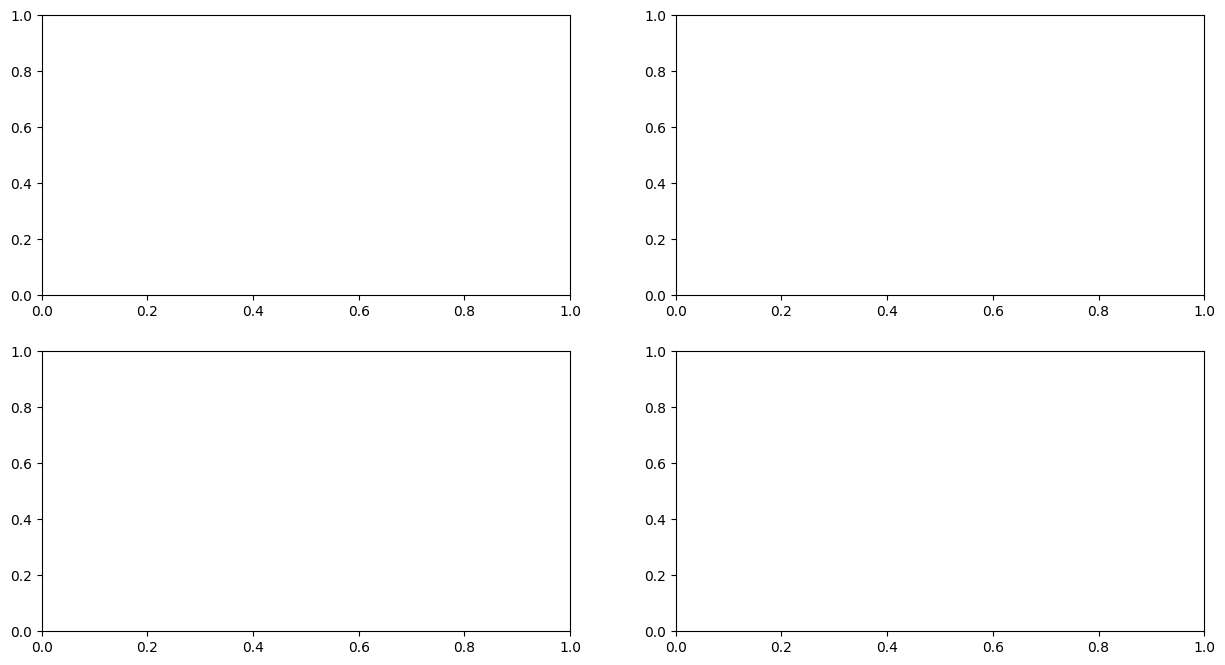

In [4]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

plot_acf(monthly_data['Sales'], lags=12, ax=ax[0, 0], title='ACF on non-stationary')
plot_pacf(monthly_data['Sales'], lags=12, ax=ax[0, 1], method='ols', title='PACF on non-stationary')

plot_acf(monthly_data['Sales_Diff'], lags=12, ax=ax[1, 0], title='ACF on differenced/stationary')
plot_pacf(monthly_data['Sales_Diff'], lags=12, ax=ax[1, 1], method='ols', title='PACF on differenced/stationary')

plt.tight_layout()
plt.show()

In [ ]:
# split the data into training and testing sets
train_size = int(len(monthly_data) * 0.8)
train, test = monthly_data.iloc[:train_size], monthly_data.iloc[train_size:]

In [ ]:
display(f'Train shape: {train.shape}')
display(train.head())

display(f'Test shape: {test.shape}')
test.head()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

# fit the model
arima = ARIMA(train['Sales'], order=(1, 1, 1))
arima_model = arima.fit()

# make predictions from model
pred = arima_model.forecast(steps=len(test))

# calculate the error
error = root_mean_squared_error(test['Sales'], pred)
print('Test RMSE: %.3f' % error)

# plot the results
plt.figure(figsize=(15, 4))
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(test.index, pred, color='red', label='Forecast')
plt.xlabel('Date')
plt.ylabel('Difference in Sales')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()
